In [1]:
import numpy as np

# Simulate flipping a fair coin n times, many times over
def experiment(n, num_trials=1000):
    results = []
    for _ in range(num_trials):
        flips = np.random.rand(n) < 0.5  # True = heads
        results.append(flips.mean())     # fraction of heads
    return np.array(results)

small = experiment(n=10)
large = experiment(n=10000)

print("n=10:    mean =", small.mean(), " std =", small.std())
print("n=10000: mean =", large.mean(), " std =", large.std())
print(large.std()/small.std())

n=10:    mean = 0.5056999999999999  std = 0.15873723570731602
n=10000: mean = 0.49969489999999994  std = 0.004982644276887524
0.03138925945563684


Matplotlib is building the font cache; this may take a moment.


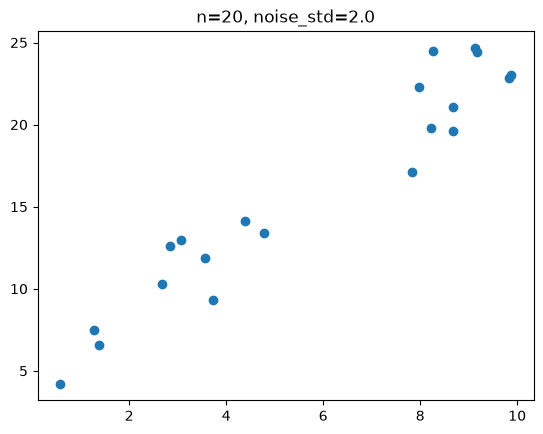

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def make_data(n, noise_std, true_slope=2.0, true_intercept=5.0):
    x = np.random.uniform(0, 10, n)
    noise = np.random.normal(0, noise_std, n)
    y = true_slope * x + true_intercept + noise
    return x, y

# Try it once
x, y = make_data(n=20, noise_std=2.0)
plt.scatter(x, y)
plt.title("n=20, noise_std=2.0")
plt.show()

In [3]:
def fit_and_compare(n, noise_std, true_slope=2.0, true_intercept=5.0):
    x, y = make_data(n, noise_std, true_slope, true_intercept)
    # Least-squares fit: numpy does this in one line
    slope_est, intercept_est = np.polyfit(x, y, 1)
    print(f"n={n}, noise_std={noise_std}")
    print(f"  true:      slope={true_slope}, intercept={true_intercept}")
    print(f"  estimated: slope={slope_est:.3f}, intercept={intercept_est:.3f}")

fit_and_compare(n=20, noise_std=2.0)

n=20, noise_std=2.0
  true:      slope=2.0, intercept=5.0
  estimated: slope=1.872, intercept=6.163


In [4]:
fit_and_compare(n=5,    noise_std=2.0)
fit_and_compare(n=500,  noise_std=2.0)
fit_and_compare(n=5,    noise_std=10.0)
fit_and_compare(n=500,  noise_std=10.0)

n=5, noise_std=2.0
  true:      slope=2.0, intercept=5.0
  estimated: slope=1.770, intercept=5.656
n=500, noise_std=2.0
  true:      slope=2.0, intercept=5.0
  estimated: slope=1.989, intercept=5.261
n=5, noise_std=10.0
  true:      slope=2.0, intercept=5.0
  estimated: slope=2.358, intercept=-3.328
n=500, noise_std=10.0
  true:      slope=2.0, intercept=5.0
  estimated: slope=2.040, intercept=5.331
